In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# --------------------------------------------------
# Project paths
# --------------------------------------------------

# amy_eda.ipynb is stored inside /notebooks
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

TABLES_DIR = PROJECT_ROOT / "tables"

PART1_DIR = TABLES_DIR / "part_1"
PART2_DIR = TABLES_DIR / "part_2"
PART3_DIR = TABLES_DIR / "part_3"
PART4_DIR = TABLES_DIR / "part_4"

print("Project root:", PROJECT_ROOT)
print("Tables directory exists:", TABLES_DIR.exists())

Project root: /Users/amyliu/Desktop/MAST30034_Project_2
Tables directory exists: True


In [3]:
# --------------------------------------------------
# Load Part 1 reference/entity tables
# --------------------------------------------------

consumer_fraud = pd.read_csv(
    PART1_DIR / "consumer_fraud_probability.csv"
)

consumer_details = pd.read_parquet(
    PART1_DIR / "consumer_user_details.parquet"
)

merchant_fraud = pd.read_csv(
    PART1_DIR / "merchant_fraud_probability.csv"
)

consumers = pd.read_csv(
    PART1_DIR / "tbl_consumer.csv"
)

merchants = pd.read_parquet(
    PART1_DIR / "tbl_merchants.parquet"
)

part1_tables = {
    "consumer_fraud": consumer_fraud,
    "consumer_details": consumer_details,
    "merchant_fraud": merchant_fraud,
    "consumers": consumers,
    "merchants": merchants
}

In [4]:
for name, df in part1_tables.items():
    print(f"{name}: {df.shape}")

consumer_fraud: (34864, 3)
consumer_details: (499999, 2)
merchant_fraud: (114, 3)
consumers: (499999, 1)
merchants: (4026, 2)


In [5]:
# --------------------------------------------------
# Load partitioned transaction data
# --------------------------------------------------

def load_transaction_part(part_dir):
    """
    Load all parquet files from a transaction partition directory.

    Parameters
    ----------
    part_dir : Path
        Path to tables/part_2, part_3, or part_4.

    Returns
    -------
    pd.DataFrame
        Combined transaction dataframe.
    """
    
    parquet_files = sorted(part_dir.glob("**/*.parquet"))

    if not parquet_files:
        raise FileNotFoundError(
            f"No parquet files found in {part_dir}"
        )

    frames = [
        pd.read_parquet(file)
        for file in parquet_files
    ]

    df = pd.concat(
        frames,
        ignore_index=True
    )

    return df

In [6]:
transactions_2 = load_transaction_part(PART2_DIR)
transactions_3 = load_transaction_part(PART3_DIR)
transactions_4 = load_transaction_part(PART4_DIR)

print("Part 2:", transactions_2.shape)
print("Part 3:", transactions_3.shape)
print("Part 4:", transactions_4.shape)

Part 2: (3643266, 4)
Part 3: (4508106, 4)
Part 4: (6044133, 4)


In [7]:
# --------------------------------------------------
# Generic EDA
# --------------------------------------------------

def basic_eda(df, name="DataFrame"):
    """
    Perform basic data-quality checks.

    Reports:
    - shape
    - column names
    - data types
    - missing values
    - duplicated rows
    - numeric summary statistics
    """
    
    print("=" * 60)
    print(name)
    print("=" * 60)

    print(f"\nRows: {len(df):,}")
    print(f"Columns: {df.shape[1]:,}")

    print("\nColumn types:")
    display(
        pd.DataFrame({
            "dtype": df.dtypes
        })
    )

    missing = pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_percent": df.isna().mean() * 100
    }).sort_values(
        "missing_percent",
        ascending=False
    )

    print("\nMissing values:")
    display(missing)

    duplicate_count = df.duplicated().sum()
    duplicate_percent = df.duplicated().mean() * 100

    print(f"\nDuplicate rows: {duplicate_count:,}")
    print(f"Percentage duplicated: {duplicate_percent:.2f}%")

    numeric_columns = df.select_dtypes(
        include=np.number
    ).columns

    if len(numeric_columns) > 0:
        print("\nNumeric summary:")
        display(
            df[numeric_columns].describe().T
        )

In [8]:
basic_eda(
    merchants,
    "Merchant Data"
)

Merchant Data

Rows: 4,026
Columns: 2

Column types:


,dtype
name,object
tags,object



Missing values:


,missing_count,missing_percent
name,0,0.0
tags,0,0.0



Duplicate rows: 0
Percentage duplicated: 0.00%


In [9]:
# --------------------------------------------------
# Transaction-specific EDA
# --------------------------------------------------

def transaction_eda(df, value_col="dollar_value"):
    """
    Perform transaction-specific EDA for dollar values.
    """
    
    if value_col not in df.columns:
        raise KeyError(
            f"{value_col} not found in dataframe."
        )

    values = df[value_col].dropna()

    print("=" * 60)
    print(f"Transaction analysis: {value_col}")
    print("=" * 60)

    quantiles = values.quantile([
        0,
        0.01,
        0.05,
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99,
        0.995,
        0.999,
        1
    ])

    print("\nQuantiles:")
    display(
        quantiles.to_frame("value")
    )

    print(
        f"\nRaw skewness: "
        f"{values.skew():.4f}"
    )

    log_values = np.log1p(
        values[values >= 0]
    )

    print(
        f"Log-transformed skewness: "
        f"{log_values.skew():.4f}"
    )

In [10]:
def plot_transaction_distributions(
    df,
    value_col="dollar_value",
    trim_quantile=0.99
):
    """
    Plot raw, trimmed, and log-scale transaction distributions.
    """

    values = df[value_col].dropna()

    # Raw distribution
    plt.figure(figsize=(10, 5))
    plt.hist(
        values,
        bins=100
    )
    plt.xlabel("Dollar value")
    plt.ylabel("Number of transactions")
    plt.title(
        "Distribution of Transaction Dollar Values"
    )
    plt.show()

    # Trimmed distribution
    cutoff = values.quantile(
        trim_quantile
    )

    trimmed = values[
        values <= cutoff
    ]

    plt.figure(figsize=(10, 5))
    plt.hist(
        trimmed,
        bins=100
    )
    plt.xlabel("Dollar value ($)")
    plt.ylabel("Number of transactions")
    plt.title(
        f"Distribution Below "
        f"{trim_quantile:.0%} Percentile"
    )
    plt.show()

    # Log-scale x-axis
    positive_values = values[
        values > 0
    ]

    plt.figure(figsize=(10, 5))
    plt.hist(
        positive_values,
        bins=np.logspace(
            np.log10(
                positive_values.min()
            ),
            np.log10(
                positive_values.max()
            ),
            100
        )
    )

    plt.xscale("log")
    plt.xlabel(
        "Dollar value ($) — log scale"
    )
    plt.ylabel(
        "Number of transactions"
    )
    plt.title(
        "Distribution of Transaction Values "
        "(Log Scale)"
    )
    plt.show()

Transaction analysis: dollar_value

Quantiles:


,value
0.000,9.756658e-08
0.010,1.258890e+00
0.050,5.514619e+00
0.100,1.045243e+01
0.250,2.615198e+01
0.500,6.223763e+01
0.750,1.506123e+02
0.900,3.593869e+02
0.950,5.906283e+02
0.990,1.622895e+03



Raw skewness: 29.7923
Log-transformed skewness: 0.0011


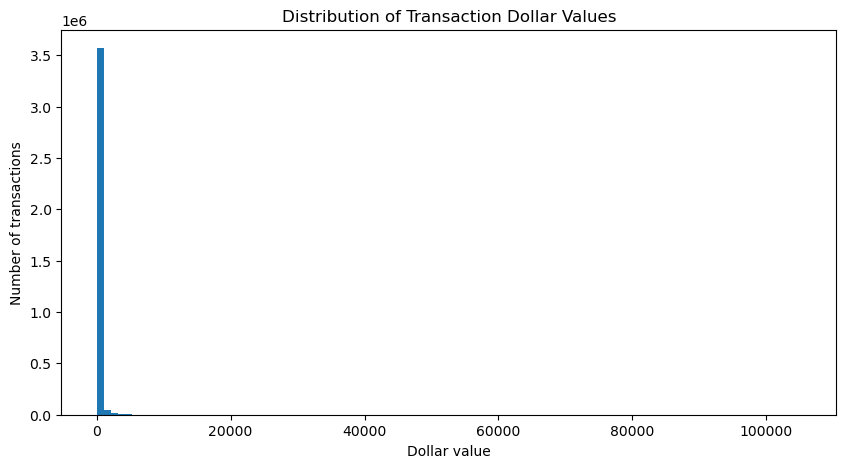

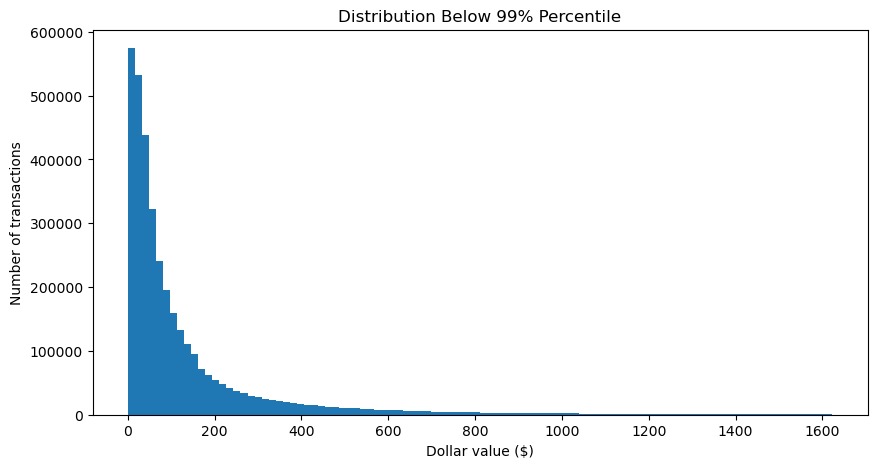

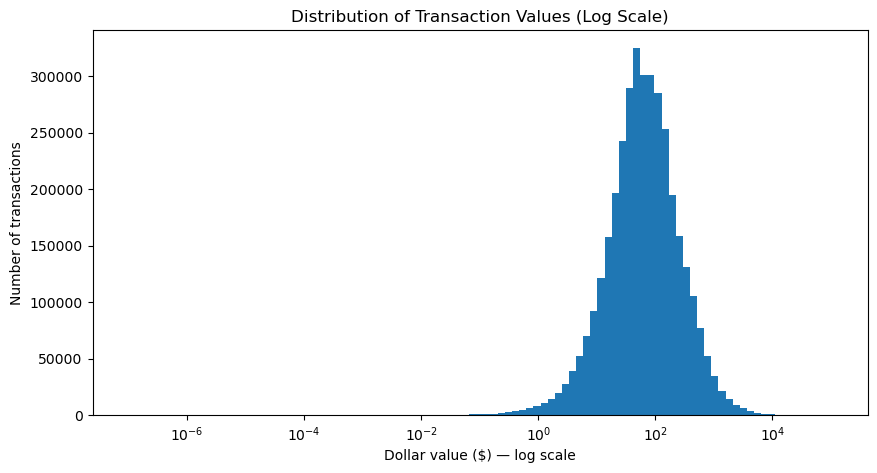

In [11]:
transaction_eda(
    transactions_2
)

plot_transaction_distributions(
    transactions_2
)

In [12]:
# --------------------------------------------------
# Initial transaction cleaning
# --------------------------------------------------

def clean_transactions(
    df,
    value_col="dollar_value",
    remove_duplicates=True,
    remove_missing_values=True,
    remove_non_positive=False,
    upper_quantile=None
):
    """
    Apply agreed transaction cleaning rules.

    Parameters are configurable so team decisions
    can be changed later without rewriting the function.
    """

    cleaned = df.copy()

    initial_rows = len(cleaned)

    # Remove duplicate rows
    if remove_duplicates:
        cleaned = cleaned.drop_duplicates()

    # Remove missing transaction values
    if (
        remove_missing_values
        and value_col in cleaned.columns
    ):
        cleaned = cleaned.dropna(
            subset=[value_col]
        )

    # Optional:
    # Remove zero / negative transaction values
    if (
        remove_non_positive
        and value_col in cleaned.columns
    ):
        cleaned = cleaned[
            cleaned[value_col] > 0
        ]

    # Optional:
    # Remove extreme upper-tail observations
    if (
        upper_quantile is not None
        and value_col in cleaned.columns
    ):
        cutoff = cleaned[
            value_col
        ].quantile(
            upper_quantile
        )

        cleaned = cleaned[
            cleaned[value_col] <= cutoff
        ]

    final_rows = len(cleaned)

    print(
        f"Rows before cleaning: "
        f"{initial_rows:,}"
    )

    print(
        f"Rows after cleaning: "
        f"{final_rows:,}"
    )

    print(
        f"Rows removed: "
        f"{initial_rows - final_rows:,}"
    )

    return cleaned.reset_index(
        drop=True
    )

In [13]:
transactions_2_clean = clean_transactions(
    transactions_2,
    remove_duplicates=True,
    remove_missing_values=True,
    remove_non_positive=False,
    upper_quantile=None
)

Rows before cleaning: 3,643,266
Rows after cleaning: 3,643,266
Rows removed: 0


In [14]:
# --------------------------------------------------
# Compare before and after cleaning
# --------------------------------------------------

def compare_cleaning(
    before,
    after,
    value_col="dollar_value"
):
    """
    Compare transaction data before and after cleaning.
    """

    comparison = pd.DataFrame({
        "Before": [
            len(before),
            before[value_col].isna().sum(),
            before.duplicated().sum(),
            before[value_col].mean(),
            before[value_col].median(),
            before[value_col].max(),
            before[value_col].skew()
        ],

        "After": [
            len(after),
            after[value_col].isna().sum(),
            after.duplicated().sum(),
            after[value_col].mean(),
            after[value_col].median(),
            after[value_col].max(),
            after[value_col].skew()
        ]
    }, index=[
        "Rows",
        "Missing dollar values",
        "Duplicate rows",
        "Mean dollar value",
        "Median dollar value",
        "Maximum dollar value",
        "Skewness"
    ])

    return comparison

In [15]:
compare_cleaning(
    transactions_2,
    transactions_2_clean
)

,Before,After
Rows,3.643266e+06,3.643266e+06
Missing dollar values,0.000000e+00,0.000000e+00
Duplicate rows,0.000000e+00,0.000000e+00
Mean dollar value,1.662799e+02,1.662799e+02
Median dollar value,6.223763e+01,6.223763e+01
Maximum dollar value,1.051939e+05,1.051939e+05
Skewness,2.979229e+01,2.979229e+01


In [16]:
# apply same cleaning for parts 2-4
transactions_2_clean = clean_transactions(
    transactions_2
)

transactions_3_clean = clean_transactions(
    transactions_3
)

transactions_4_clean = clean_transactions(
    transactions_4
)
transactions_2_clean = clean_transactions(
    transactions_2,
    remove_non_positive=True
)

Rows before cleaning: 3,643,266
Rows after cleaning: 3,643,266
Rows removed: 0
Rows before cleaning: 4,508,106
Rows after cleaning: 4,508,106
Rows removed: 0
Rows before cleaning: 6,044,133
Rows after cleaning: 6,044,133
Rows removed: 0
Rows before cleaning: 3,643,266
Rows after cleaning: 3,643,266
Rows removed: 0


In [17]:
transactions_2_clean = clean_transactions(
    transactions_2,
    remove_non_positive=True,
    upper_quantile=0.999
)

Rows before cleaning: 3,643,266
Rows after cleaning: 3,639,622
Rows removed: 3,644


In [18]:
# --------------------------------------------------
# Combined transaction dataset
# --------------------------------------------------

transactions_clean = pd.concat(
    [
        transactions_2_clean,
        transactions_3_clean,
        transactions_4_clean
    ],
    ignore_index=True
)

print(
    "Combined cleaned transactions:",
    transactions_clean.shape
)

Combined cleaned transactions: (14191861, 4)


In [19]:
# --------------------------------------------------
# Part 1 cleaning skeleton
# --------------------------------------------------

def clean_consumers(df):
    cleaned = df.copy()

    cleaned = cleaned.drop_duplicates()

    # TODO:
    # Add agreed consumer cleaning rules

    return cleaned.reset_index(
        drop=True
    )

In [20]:
def clean_merchants(df):
    cleaned = df.copy()

    cleaned = cleaned.drop_duplicates()

    # TODO:
    # Add agreed merchant cleaning rules

    return cleaned.reset_index(
        drop=True
    )

In [21]:
for name, df in part1_tables.items():
    basic_eda(
        df,
        name
    )

consumer_fraud

Rows: 34,864
Columns: 3

Column types:


,dtype
user_id,int64
order_datetime,object
fraud_probability,float64



Missing values:


,missing_count,missing_percent
user_id,0,0.0
order_datetime,0,0.0
fraud_probability,0,0.0



Duplicate rows: 99
Percentage duplicated: 0.28%

Numeric summary:


...


Duplicate rows: 0
Percentage duplicated: 0.00%
merchants

Rows: 4,026
Columns: 2

Column types:


,dtype
name,object
tags,object



Missing values:


,missing_count,missing_percent
name,0,0.0
tags,0,0.0



Duplicate rows: 0
Percentage duplicated: 0.00%
